
# TASK 3: DATA CLEANING, DESCRIPTIVE ANALYSIS & PREDICTIVE MODEL




# Import libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. LOAD DATA

In [4]:
df = pd.read_csv("LondonBikeJourneyAug2023.csv")

print("Raw dataset shape:", df.shape)
print(df.head())


Raw dataset shape: (776527, 11)
      Number       Start date  Start station number  \
0  132825189  08/01/2023 0:00                  1190   
1  132825190  08/01/2023 0:00                  1190   
2  132825191  08/01/2023 0:00                   983   
3  132825192  08/01/2023 0:01                  3479   
4  132825193  08/01/2023 0:01                  1219   

                           Start station         End date  End station number  \
0  Kennington Lane Rail Bridge, Vauxhall  08/01/2023 0:17                1059   
1  Kennington Lane Rail Bridge, Vauxhall  08/01/2023 0:17                1059   
2                    Euston Road, Euston  08/01/2023 0:11                3500   
3    Old Brompton Road, South Kensington  08/01/2023 0:12                1140   
4                  Lower Marsh, Waterloo  08/01/2023 0:17              200056   

                   End station  Bike number Bike model Total duration  \
0  Albert Embankment, Vauxhall        23715    CLASSIC        16m 46s   
1  A

# 2. DATA CLEANING & FEATURE ENGINEERING

In [5]:
# Convert timestamps to datetime
df["Start dt"] = pd.to_datetime(df["Start date"])
df["End dt"] = pd.to_datetime(df["End date"])

# Create trip duration in minutes from milliseconds
df["duration_min"] = df["Total duration (ms)"] / (1000 * 60)

# Engineer time-based features
df["day"] = df["Start dt"].dt.date
df["hour"] = df["Start dt"].dt.hour
df["day_of_week"] = df["Start dt"].dt.dayofweek  # Monday = 0
df["weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# 3. CHECK DATA QUALITY

In [6]:
print("\nMissing values per column:")
print(df.isna().sum())

print("\nBasic duration stats:")
print(df["duration_min"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


Missing values per column:
Number                  0
Start date              0
Start station number    0
Start station           0
End date                0
End station number      0
End station             0
Bike number             0
Bike model              0
Total duration          0
Total duration (ms)     0
Start dt                0
End dt                  0
duration_min            0
day                     0
hour                    0
day_of_week             0
weekend                 0
dtype: int64

Basic duration stats:
count    776527.000000
mean         25.916429
std         288.167013
min           0.021783
50%          13.979500
75%          23.203808
90%          36.450357
95%          51.338407
99%         112.878322
max      124031.797433
Name: duration_min, dtype: float64


# 4. DESCRIPTIVE STATISTICS & VISUALISATIONS

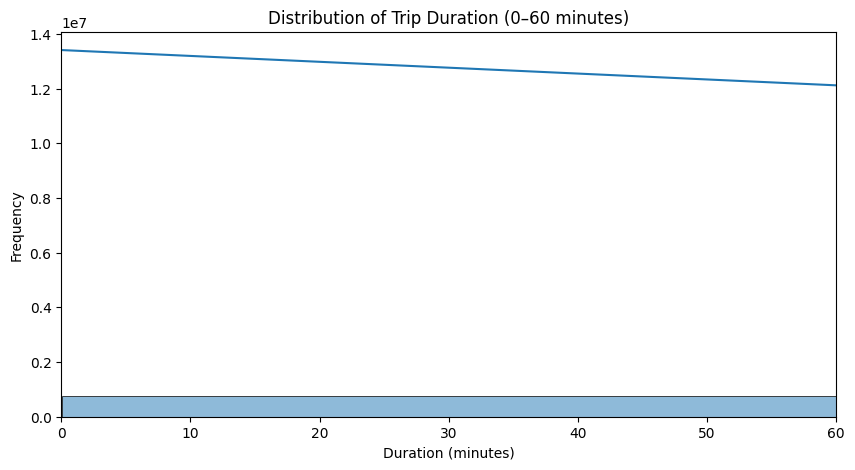

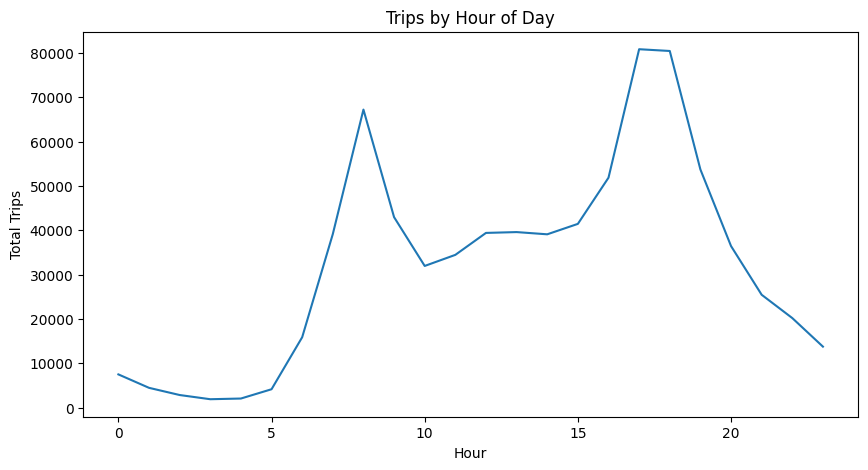

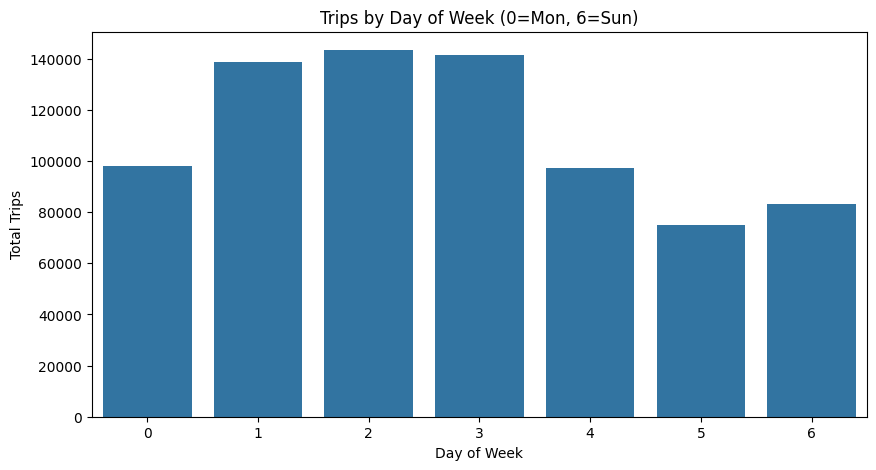

In [7]:
# Histogram of trip durations
plt.figure(figsize=(10, 5))
sns.histplot(df["duration_min"], bins=100, kde=True)
plt.xlim(0, 60)
plt.title("Distribution of Trip Duration (0–60 minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

# Trips per hour
hourly_counts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Trips")
plt.show()

# Trips by day of week
dow_counts = df["day_of_week"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=dow_counts.index, y=dow_counts.values)
plt.title("Trips by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Total Trips")
plt.show()


# 5. AGGREGATE TO DAILY LEVEL FOR MODELLING

In [8]:
daily = df.groupby("day").size().reset_index(name="daily_trips")
daily["day_of_week"] = pd.to_datetime(daily["day"]).dt.dayofweek
daily["weekend"] = daily["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

print("\nDaily dataset:")
print(daily.head())


Daily dataset:
          day  daily_trips  day_of_week  weekend
0  2023-08-01        30055            1        0
1  2023-08-02        20622            2        0
2  2023-08-03        29822            3        0
3  2023-08-04        24950            4        0
4  2023-08-05        11638            5        1


# 6. PREPARE DATA FOR PREDICTIVE MODEL

In [9]:
# One-hot encode day of week
X = pd.get_dummies(daily["day_of_week"], prefix="dow", drop_first=True)
X["weekend"] = daily["weekend"]

y = daily["daily_trips"]


# 7. FIT LINEAR REGRESSION MODEL

In [10]:
model = LinearRegression()
model.fit(X, y)

# Predictions
preds = model.predict(X)

# Model performance
r2 = r2_score(y, preds)
print(f"\nModel R² Score: {r2:.3f}")

# Coefficient interpretation
coeffs = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
print(coeffs)


Model R² Score: 0.567

Model Coefficients:
  Variable  Coefficient
0    dow_1  3194.750000
1    dow_2  4132.150000
2    dow_3  3729.750000
3    dow_4  -246.000000
4    dow_5 -2641.166667
5    dow_6  -555.916667
6  weekend -3197.083333


# 8. VISUALISE PREDICTED VS ACTUAL DAILY DEMAND

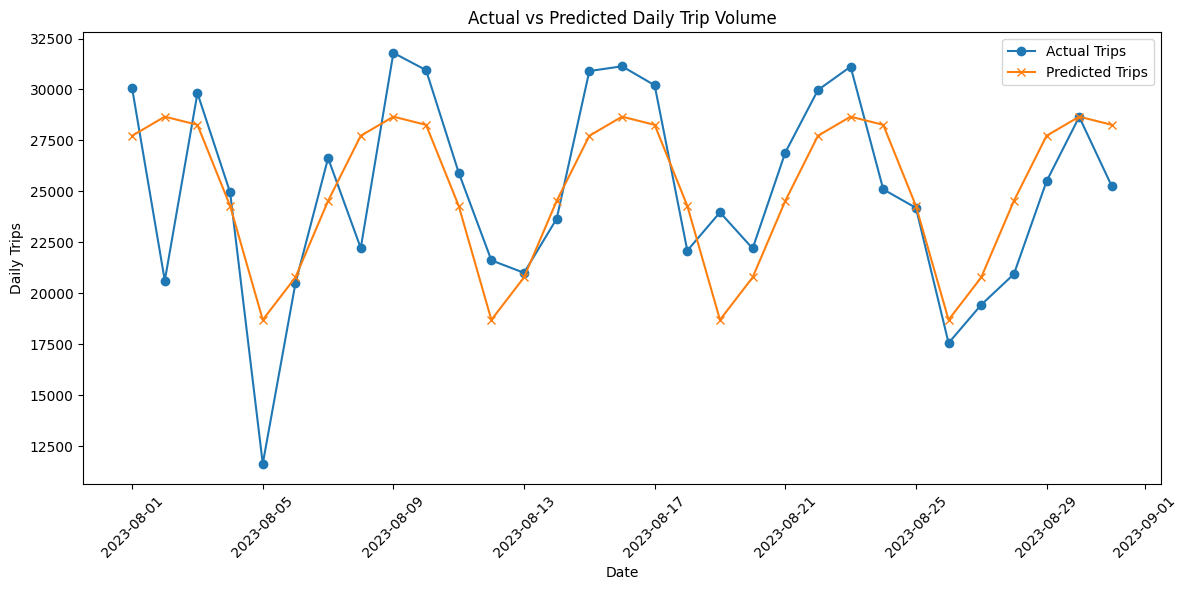

In [11]:
plt.figure(figsize=(12,6))
plt.plot(daily["day"], y, label="Actual Trips", marker="o")
plt.plot(daily["day"], preds, label="Predicted Trips", marker="x")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Daily Trips")
plt.title("Actual vs Predicted Daily Trip Volume")
plt.legend()
plt.tight_layout()
plt.show()


# 9. VISUALISE PREDICTIONS BY DAY OF WEEK

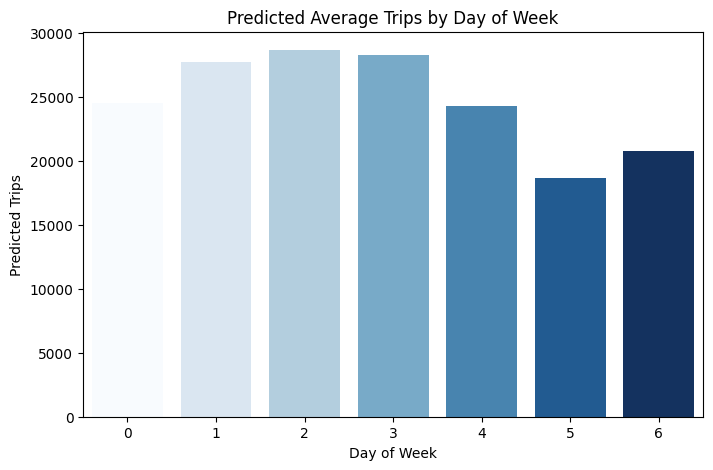

In [13]:
avg_predictions = preds.reshape(-1, 1)
daily["predicted"] = preds

plt.figure(figsize=(8, 5))
sns.barplot(
    data=daily.groupby("day_of_week")[["daily_trips", "predicted"]].mean().reset_index(),
    x="day_of_week",
    y="predicted",
    hue="day_of_week",
    palette="Blues",
    legend=False
)
plt.title("Predicted Average Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Predicted Trips")
plt.show()
